## Pumpkin Pricing

Load up required libraries and dataset. Convert the data to a dataframe containing a subset of the data: 

- Only get pumpkins priced by the bushel
- Convert the date to a month
- Calculate the price to be an average of high and low prices
- Convert the price to reflect the pricing by bushel quantity

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from datetime import datetime

pumpkins = pd.read_csv('../data/US-pumpkins.csv')

pumpkins.head()


,City Name,Type,Package,Variety,Sub Variety,Grade,Date,Low Price,High Price,Mostly Low,...,Unit of Sale,Quality,Condition,Appearance,Storage,Crop,Repack,Trans Mode,Unnamed: 24,Unnamed: 25
0,BALTIMORE,NaN,24 inch bins,NaN,NaN,NaN,4/29/17,270.0,280.0,270.0,...,NaN,NaN,NaN,NaN,NaN,NaN,E,NaN,NaN,NaN
1,BALTIMORE,NaN,24 inch bins,NaN,NaN,NaN,5/6/17,270.0,280.0,270.0,...,NaN,NaN,NaN,NaN,NaN,NaN,E,NaN,NaN,NaN
2,BALTIMORE,NaN,24 inch bins,HOWDEN TYPE,NaN,NaN,9/24/16,160.0,160.0,160.0,...,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN
3,BALTIMORE,NaN,24 inch bins,HOWDEN TYPE,NaN,NaN,9/24/16,160.0,160.0,160.0,...,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN
4,BALTIMORE,NaN,24 inch bins,HOWDEN TYPE,NaN,NaN,11/5/16,90.0,100.0,90.0,...,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN


In [4]:
pumpkins = pumpkins[pumpkins['Package'].str.contains('bushel', case=True, regex=True)]

columns_to_select = ['Package', 'Variety', 'City Name', 'Low Price', 'High Price', 'Date']
pumpkins = pumpkins.loc[:, columns_to_select]

price = (pumpkins['Low Price'] + pumpkins['High Price']) / 2

month = pd.DatetimeIndex(pumpkins['Date']).month
day_of_year = pd.to_datetime(pumpkins['Date']).apply(lambda dt: (dt-datetime(dt.year,1,1)).days)

new_pumpkins = pd.DataFrame(
    {'Month': month, 
     'DayOfYear' : day_of_year, 
     'Variety': pumpkins['Variety'], 
     'City': pumpkins['City Name'], 
     'Package': pumpkins['Package'], 
     'Low Price': pumpkins['Low Price'],
     'High Price': pumpkins['High Price'], 
     'Price': price})

new_pumpkins.loc[new_pumpkins['Package'].str.contains('1 1/9'), 'Price'] = price/1.1
new_pumpkins.loc[new_pumpkins['Package'].str.contains('1/2'), 'Price'] = price*2

new_pumpkins.head()


C:\Users\abdullah\AppData\Local\Temp\ipykernel_28360\2637987050.py:9: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  day_of_year = pd.to_datetime(pumpkins['Date']).apply(lambda dt: (dt-datetime(dt.year,1,1)).days)


,Month,DayOfYear,Variety,City,Package,Low Price,High Price,Price
70,9,267,PIE TYPE,BALTIMORE,1 1/9 bushel cartons,15.0,15.0,13.636364
71,9,267,PIE TYPE,BALTIMORE,1 1/9 bushel cartons,18.0,18.0,16.363636
72,10,274,PIE TYPE,BALTIMORE,1 1/9 bushel cartons,18.0,18.0,16.363636
73,10,274,PIE TYPE,BALTIMORE,1 1/9 bushel cartons,17.0,17.0,15.454545
74,10,281,PIE TYPE,BALTIMORE,1 1/9 bushel cartons,15.0,15.0,13.636364


A basic scatterplot reminds us that we only have month data from August through December. We probably need more data to be able to draw conclusions in a linear fashion.

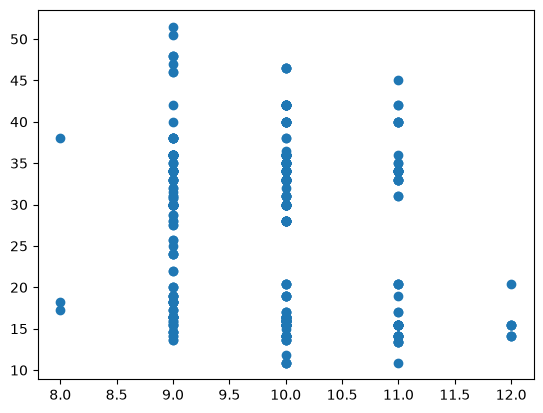

In [5]:
import matplotlib.pyplot as plt
plt.scatter('Month','Price',data=new_pumpkins)

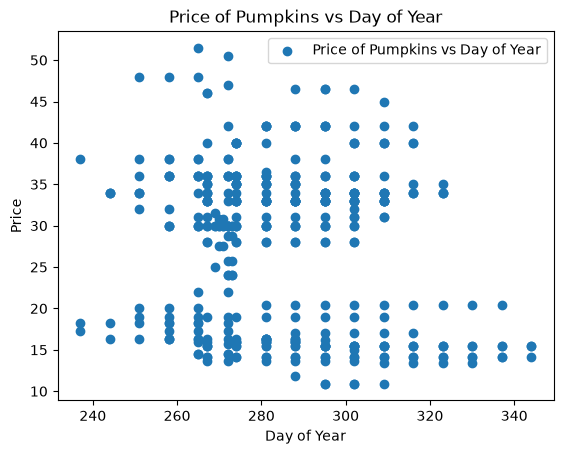

In [6]:

plt.scatter('DayOfYear','Price',data=new_pumpkins)
plt.xlabel('Day of Year')
plt.ylabel('Price')
plt.title('Price of Pumpkins vs Day of Year')
plt.legend(['Price of Pumpkins vs Day of Year'])
plt.show()

after that will ne my notes now 
we can find correlation between two attiributes with corr function letss see

In [7]:
print(new_pumpkins['Month'].corr(new_pumpkins['Price']))
print(new_pumpkins['DayOfYear'].corr(new_pumpkins['Price']))

-0.14878293554077526
-0.1667332249274541


now corr function returns close  to 1 one when two attiribute have strong positive relationship between them and retturns 0  when there isn't, if the relationship is negative it will return close to -1, using attiributes  that doesnt have strong relationship with the label data for training models is really bad

In [8]:
new_pumpkins['Variety'].value_counts()

Variety
MINIATURE                   262
PIE TYPE                    144
FAIRYTALE                     7
MIXED HEIRLOOM VARIETIES      2
Name: count, dtype: int64

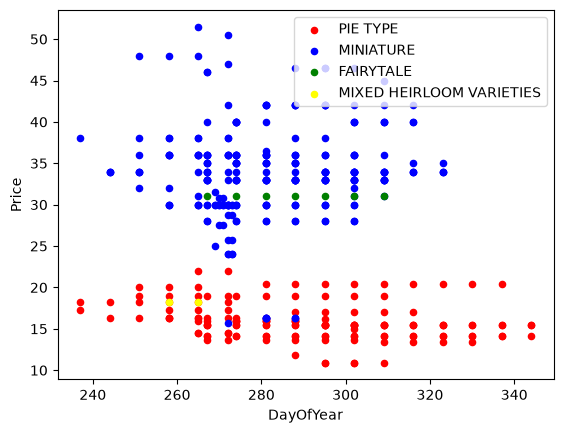

In [9]:
colors = ['red','blue', 'green', 'yellow']

ax = None

for i, var in enumerate(new_pumpkins['Variety'].unique()):
    # that loop will iterate through each unique variety of pumpkin
    #  in the dataset. For each variety, it will filter the data to
    #  include only that variety and then create a scatter plot of
    #  the price against the day of the year. Each variety will be
    #  plotted in a different color, as specified in the colors
    #  list. The ax variable is used to ensure that all scatter 
    # plots are drawn on the same axes, allowing for easy
    #  comparison between varieties.
    var_data = new_pumpkins[new_pumpkins['Variety'] == var]
    ax = var_data.plot.scatter(x='DayOfYear', y='Price', color=colors[i], label=var, ax=ax)

<Axes: title={'center': 'Average Price of Pumpkins per Variety'}, xlabel='Variety', ylabel='Average Price'>

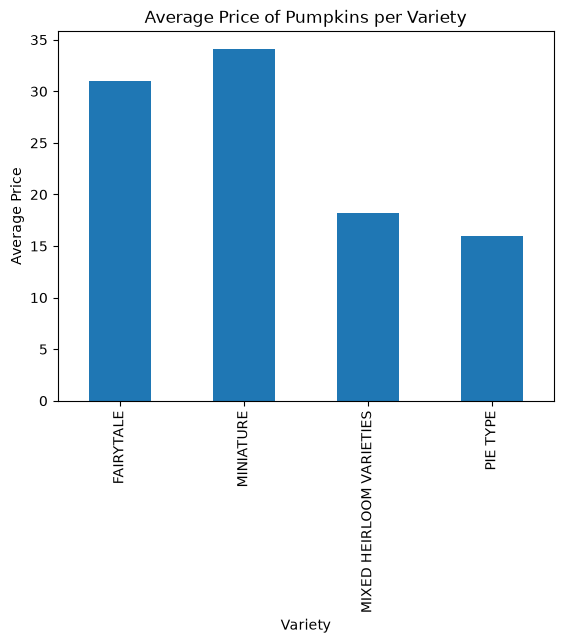

In [10]:
new_pumpkins.groupby('Variety')['Price'].mean().plot(kind='bar', title='Average Price of Pumpkins per Variety', xlabel='Variety', ylabel='Average Price')

the thing I couldnt understand is why dont we use month and pie type to create a model it's gonna be way better then day of the year

<Axes: xlabel='DayOfYear', ylabel='Price'>

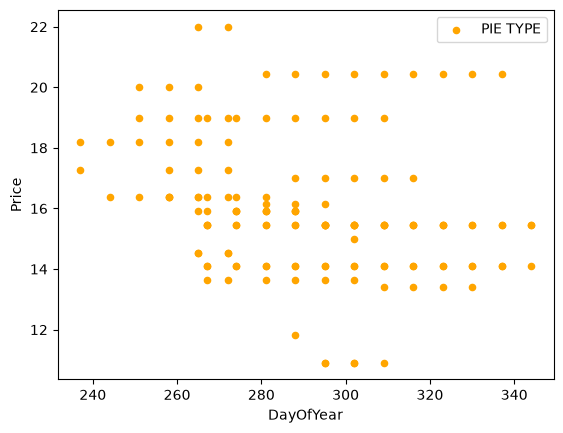

In [11]:
pie_pumpkins = new_pumpkins[new_pumpkins['Variety'] == 'PIE TYPE']
pie_pumpkins.plot.scatter(x='DayOfYear', y='Price', color='orange', label='PIE TYPE')

In [12]:
print(pie_pumpkins['Month'].corr(pie_pumpkins['Price']), pie_pumpkins['DayOfYear'].corr(pie_pumpkins['Price']))

-0.23841413206125747 -0.2669192282197318


bşggest coorelation so far -0.2669192282197318 is between the price of pie pumpkins and the day of the year.
This negative correlation suggests that as the year progresses, the price of pie pumpkins tends to decrease.

now we will create linear and polynomial models to try wich is best to fit 

In [13]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error


X = pie_pumpkins[['DayOfYear']]
y = pie_pumpkins['Price']

x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [16]:


model = LinearRegression()
model.fit(x_train, y_train)

predictions = model.predict(x_test)

mse = np.sqrt(mean_squared_error(y_test, predictions))
print("Mean Squared Error:", f"{mse:3.3} - {mse / np.mean(predictions) * 100:3.3f}% of the mean price")

Mean Squared Error: 2.34 - 14.646% of the mean price


In [17]:
score = model.score(x_test, y_test)
print("R^2 Score:", f"{score:3.3}")

R^2 Score: 0.0404


r2 value close the one better the model right now itsn't

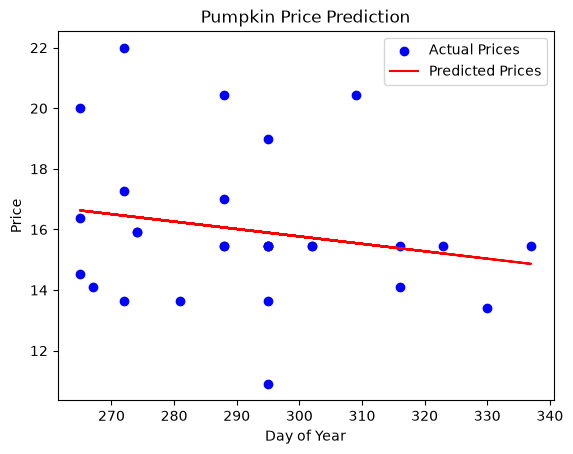

In [18]:
plt.scatter(x_test, y_test, color='blue', label='Actual Prices')
plt.plot(x_test, predictions, color='red', label='Predicted Prices')
plt.xlabel('Day of Year')
plt.ylabel('Price')
plt.title('Pumpkin Price Prediction')
plt.legend()
plt.show()

In [19]:
# we can learn slope and intercept of the line using the model's attributes
print(f"y = {model.coef_[0]}x + {model.intercept_}")

y = -0.024498026046480513x + 23.119906708317842


In [23]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline

pipeline = make_pipeline(PolynomialFeatures(degree=2), LinearRegression())

pipeline.fit(x_train, y_train)

predictions_poly = pipeline.predict(x_test)

mse = np.sqrt(mean_squared_error(y_test, predictions_poly))
print("Mean Squared Error (Polynomial):", f"{mse:3.3} - {mse / np.mean(predictions_poly) * 100:3.3f}% of the mean price")

Mean Squared Error (Polynomial): 2.36 - 14.953% of the mean price


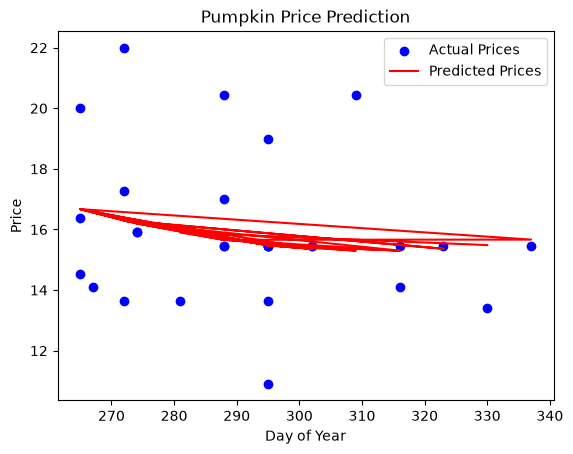

In [27]:
plt.scatter(x_test, y_test, color='blue', label='Actual Prices')
plt.plot(x_test, pipeline.predict(x_test), color='red', label='Predicted Prices')
plt.xlabel('Day of Year')
plt.ylabel('Price')
plt.title('Pumpkin Price Prediction')
plt.legend()
plt.show()

In [28]:
score = pipeline.score(x_test, y_test)
print("R^2 Score (Polynomial):", f"{score:3.3}")

R^2 Score (Polynomial): 0.0229


even I made everything the same it seems like my model is way wors then theirs I dont know why

when we wanna use categorical features that are actually strings 
we need to convert them to numerical values but assigning them with
1,2,3,4 actually gives the model hard time defining the logic behind it so we use get_dummies function it creates a column for each type of the variable then put 1 if the example in that category letss see

In [32]:
# new models give true false as output if u dont specify dtype
pd.get_dummies(new_pumpkins['Variety'])

,FAIRYTALE,MINIATURE,MIXED HEIRLOOM VARIETIES,PIE TYPE
70,False,False,False,True
71,False,False,False,True
72,False,False,False,True
73,False,False,False,True
74,False,False,False,True
...,...,...,...,...
1738,False,True,False,False
1739,False,True,False,False
1740,False,True,False,False
1741,False,True,False,False


In [36]:
X = pd.get_dummies(new_pumpkins['Variety'])
y = new_pumpkins['Price']

x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()

model.fit(x_train, y_train)

predictions = model.predict(x_test)

mse = np.sqrt(mean_squared_error(y_test, predictions))
print("Mean Squared Error (Variety):", f"{mse:3.3} - {mse / np.mean(predictions) * 100:3.3f}% of the mean price")

score = model.score(x_test, y_test)
print("R^2 Score (Variety):", f"{score:3.3}")

Mean Squared Error (Variety): 4.74 - 17.991% of the mean price
R^2 Score (Variety): 0.789


even using just a categorical feature we get a way better result lets continue and use all categoricak features

In [37]:
X = pd.get_dummies(new_pumpkins[['Variety','Month', 'City', 'Package']])
y = new_pumpkins['Price']

x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()

model.fit(x_train, y_train)

predictions = model.predict(x_test)

mse = np.sqrt(mean_squared_error(y_test, predictions))

print("Mean Squared Error (All Features):", f"{mse:3.3} - {mse / np.mean(predictions) * 100:3.3f}% of the mean price")

score = model.score(x_test, y_test)

print("R^2 Score (All Features):", f"{score:3.3}")



Mean Squared Error (All Features): 2.21 - 8.532% of the mean price
R^2 Score (All Features): 0.954


we have a way better model then before look at that 
now lets try it with polynomail

In [38]:
pipeline = make_pipeline(PolynomialFeatures(degree=2), LinearRegression())

pipeline.fit(x_train, y_train)

predictions_poly = pipeline.predict(x_test)

mse = np.sqrt(mean_squared_error(y_test, predictions_poly))
print("Mean Squared Error (Polynomial All Features):", f"{mse:3.3} - {mse / np.mean(predictions_poly) * 100:3.3f}% of the mean price")

score = pipeline.score(x_test, y_test)
print("R^2 Score (Polynomial All Features):", f"{score:3.3}")

Mean Squared Error (Polynomial All Features): 2.11 - 8.159% of the mean price
R^2 Score (Polynomial All Features): 0.958


we havent seen an awsome increase but that's still better 

this long lesson primarly teaches us about 
polynomial regression wich we use with make_pipeline and a degree
degree increase normally should give us a better performance but not all the time and it increase training cost 

and get_dummies function for turning categorical values into numerical values that model can understand 